In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches 


import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}pass_zero
</style>
""")


Infinite Impulse Response (IIR) filters are such filters which include recursion, respectively feedback, in their implementation. Their impulse response does thus not drop to zero after a given time. They can become instable due to the feedback.
However, IIR filters require less coefficients and thus less operations to get a filter with the desired effect than FIR filters.
As FIR filters, IIR filters create an output sequence $y[n]$ for an input sequence $x[n]$. However, the recursion makes the simple convolution analogy impossible.


------

# The Difference Equation

The difference equation known from FIR filters needs to be extended for IIR filters.
Recursion is included with additional coefficients $a_n$, feeding back the output signal $y[n]$ with different delays. 
The following difference function represents a second order IIR filter. Also referred to as **biquad filter**, this is a basic component for many digital filter implementations:

$$
y[n] = b_0 x[n] + b_1 x[n-1]+ b_2 x[n-2] - a_1 y[n-1] - a_2 y[n-2]
$$

<div class="alert alert-block alert-warning">
⚠️ There are different definitions of the difference equation and all related equations in relevant literature.
   Oppenheim and Schafer do not use a negative sign for the feedback coefficients ($+ a_i[n-i]$).
   We stick to the negative feedback sign, likeJulius Smith. This also aligns with the filter implemetations in SciPy. 
</div>


The general form of the difference equation for IIR filters is the following sum equation, combining both the forward and recursive elements:

$$
   y[n] =  \sum\limits_{i=0}^{i=N} b_i  x[n-i] - \sum\limits_{i=1}^{i=N} a_i  y[n-i]
$$

-----

# Implementation Structure 

The above difference equation can be transferred into signal flow diagrams, with different *implementation structures*. 
These structures can be directly implemented in actual code. Although they all translate to the same difference equation, the implementation details can have an impact on the filter's properties.
The following signal flow diagram shows the **Direct Form 1**:

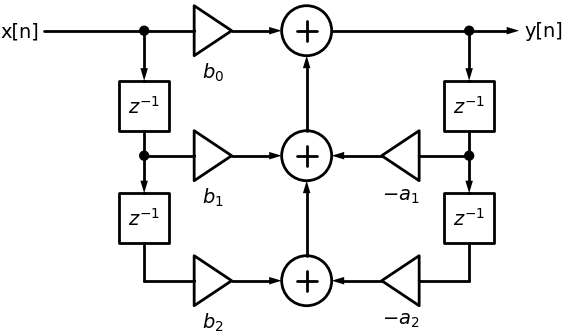

In [2]:
with schemdraw.Drawing() as d:
    d.config(unit=1, fontsize=14)
    dsp.Line().length(d.unit*2).label('x[n]', 'left').dot()

    d.push()
    dsp.Line().right()
    dsp.Amp().label('$b_0$', 'bottom')
    dsp.Arrow()
    s0 = dsp.Sum().anchor('W')
    d.pop()

    dsp.Arrow().down()
    z1 = dsp.Square(label='$z^{-1}$')
    dsp.Line().length(d.unit/2).dot()

    d.push()
    dsp.Line().right()
    dsp.Amp().label('$b_1$', 'bottom')
    dsp.Arrow()
    s1 = dsp.Sum().anchor('W')
    d.pop()

    dsp.Arrow().down(d.unit*.75)
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit*.75)
    dsp.Line().right()
    dsp.Amp().label('$b_2$', 'bottom')
    dsp.Arrow()
    s2 = dsp.Sum().anchor('W')

    dsp.Arrow().at(s2.N).toy(s1.S)
    dsp.Arrow().at(s1.N).toy(s0.S)

    dsp.Line().right(d.unit*2.75).at(s0.E).dot()
    dsp.Arrow().right().label('y[n]', 'right').hold()
    dsp.Arrow().down()
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit/2).dot()
    d.push()
    dsp.Line().left()
    a1 = dsp.Amp().label('$-a_1$', 'bottom')
    dsp.Arrow().at(a1.out).tox(s1.E)
    d.pop()

    dsp.Arrow().down(d.unit*.75)
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit*.75)
    dsp.Line().left()
    a2 = dsp.Amp().label('$-a_2$', 'bottom')
    dsp.Arrow().at(a2.out).tox(s2.E)

-----

An alternative is the **Direct Form 2**, which uses less delay units:

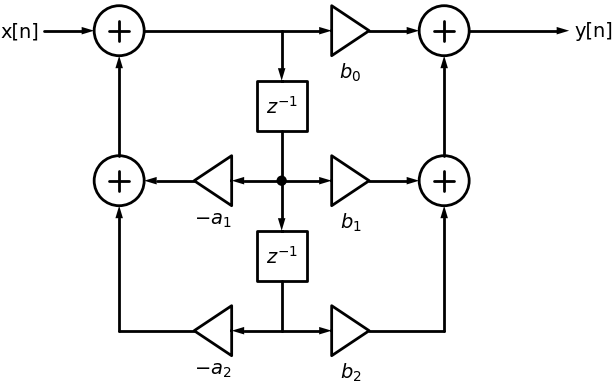

In [3]:
with schemdraw.Drawing() as d:
    d.config(unit=1, fontsize=14)
    dsp.Arrow().length(d.unit).label('x[n]', 'left')
    s1 = dsp.Sum()
    dsp.Line().length(d.unit*2.75)
    
    d.push()
    
    dsp.Arrow().down().length(d.unit)
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit)
    
    p1 = dsp.Dot()
    d.push()
    
    d.push()

    dsp.Arrow().left().length(d.unit)
    a1 = dsp.Amp().label('$-a_1$', 'bottom')
    dsp.Arrow()
    s2 = dsp.Sum()
    dsp.Arrow().at(s2.S).up().length(2)

    d.pop()

    dsp.Arrow().down().length(d.unit)
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit)
                     
    d.push()
    
    dsp.Arrow().left().length(d.unit)
    a2 = dsp.Amp().label('$-a_2$', 'bottom')
    dsp.Line().length(d.unit*1.5)
    dsp.Arrow().up().length(d.unit*2.5)

    d.pop()
    
    dsp.Arrow().right().length(d.unit)
    b2 = dsp.Amp().label('$b_2$', 'bottom')
    dsp.Line().length(d.unit*1.5)
    dsp.Arrow().up().length(d.unit*2.5)
    s3 = dsp.Sum()
    dsp.Arrow().up().length(d.unit*2)
    s4 = dsp.Sum()
    dsp.Arrow().at(s4.S).right().length(d.unit*2).label('y[n]', 'right')

    d.pop()
    dsp.Arrow().right().length(d.unit)
    b1 = dsp.Amp().label('$b_1$', 'bottom')
    dsp.Arrow().right().length(d.unit)

    d.pop()
    dsp.Arrow().right().length(d.unit)
    b0 = dsp.Amp().label('$b_0$', 'bottom')
    dsp.Arrow().right().length(d.unit)
    
    
   

-----

# Exercise

The non-standard signal flow diagram below describes an IIR filter.

- 1: Determine the order and filter coefficients.
- 2: Write the difference equation for the filter.
- 3: Calculate the impulse response on paper up to 4 samples.


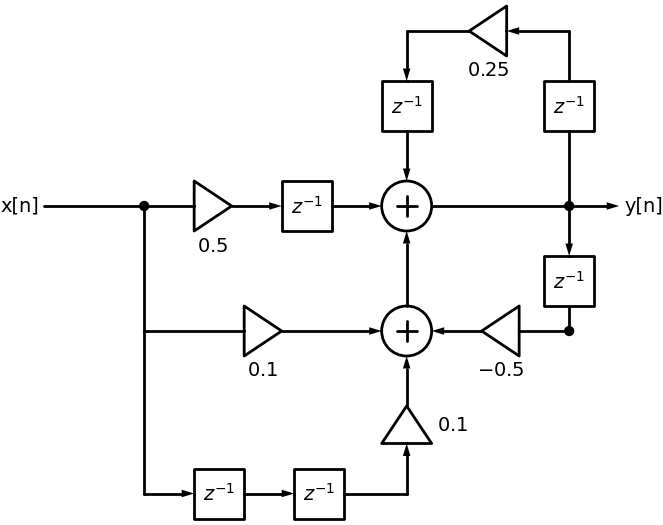

In [4]:
with schemdraw.Drawing() as d:
    d.config(unit=1, fontsize=14)
    dsp.Line().length(d.unit*2).label('x[n]', 'left').dot()

    d.push()
    dsp.Line().right()
    dsp.Amp().label('$0.5$', 'bottom')
    dsp.Arrow()
    dsp.Square(label='$z^{-1}$')
    dsp.Arrow()
    s0 = dsp.Sum().anchor('W')
    
    d.pop()

    dsp.Line().down(d.unit*2.5)

    d.push()
    
    dsp.Line().right().length(2)
    dsp.Amp().label('$0.1$', 'bottom')
    dsp.Arrow().length(2)
    s1 = dsp.Sum().anchor('W')

    d.pop()
    dsp.Line().down().length(3.25)
    dsp.Arrow().right().length(1)
    dsp.Square().label('$z^{-1}$')
    dsp.Arrow().right().length(1)
    dsp.Square().label('$z^{-1}$')
    dsp.Line().right().length(1.25)
    dsp.Arrow().up().length(1)
    dsp.Amp().label('$0.1$', 'bottom')
    dsp.Arrow().up().length(1)
      
    
    dsp.Line().right(d.unit*2.75).at(s0.E).dot()
    dsp.Arrow().right().label('y[n]', 'right').hold()
    d.push()
    dsp.Arrow().down()
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit/2).dot()

    dsp.Line().left()
    a1 = dsp.Amp().label('$-0.5$', 'bottom')
    dsp.Arrow().at(a1.out).tox(s1.E)
    dsp.Arrow().at(s1.N).up().length(1.5)
    d.pop()

    dsp.Line().up().length(1.5)
    dsp.Square().label('$z^{-1}$')
    dsp.Line().up()
    dsp.Arrow().left().length(1.25)
    a1 = dsp.Amp().label('$0.25$', 'bottom')
    dsp.Line().left().length(1.25)
    dsp.Arrow().down()
    dsp.Square().label('$z^{-1}$')
    dsp.Arrow().down()


-----

## Solution

### 1: Get Filter Coefficients

For the **feed-forward coefficients $b_i$** we start at the input node $x[n]$ and follow each path to the output node $y[n]$. We count the number of delays we have to determine the index of our coefficient:

- $b_0 = 0.1$
- $b_1 = 0.5$
- $b_2 = 0.1$

Or, as a vector:

$b = [0.1,0.5,0.1]$

For the **feedback coefficients $a_i$** we start at the output node $y[n]$ and follow each feedback path, again counting the delays on each path. We have to flip the sign of the gain elements:

- $a_1 = 0.5$
- $a_2 = -0.25$

As a vecor:

$a = [0.5, -0.25]$


-----

### 2: The Difference Equation

For the difference equation, can simply insert the coefficients into the following equation:

$$
   y[n] =  \sum\limits_{i=0}^{i=N} b_i  x[n-i] - \sum\limits_{i=1}^{i=N} a_i  y[n-i]
$$

If we take the values from the coefficients listed above, we need to flip the sign again (which corresponds to the values in the signal flow diagram):

$$
y[n] = 0.1 x[n] + 0.5 x[n-1] + 0.1 x[n-2] -0.5y[n-1] +0.25y[n-2]
$$

-----

### 3: Impulse Response

We assume the following input vector to measure the impulse response:

$x[n] = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]$


We can calculate the output $y[n]$ sample by sample:

-----

**Step 1: n=0**

$y[0] =  x[0] \cdot  b[0] = 1 \cdot 0.1 = \mathbf{0.1}$

$y[n] = [\mathbf{0.1}]$

-----

**Step 2: n=1**

$y[1] =  x[n-1] \cdot b[1] - y[0] \cdot  a[0] = 0.5 - 0.1 \cdot 0.5 = \mathbf{0.45}$

$y[n] = [0.1,\mathbf{0.45}]$

-----

**Step 3: n=2**

$y[2] = x[n-2] \cdot b[2] - y[n-1] \cdot  a[0]  - y[n-2] \cdot  a[1]$

$y[2] = 1 \cdot 0.1 - 0.45 \cdot  0.5  - 0.1  \cdot  -0.25$

$y[2] = 0.1 - 0.225 + 0.025 = \mathbf{-0.1}$

$y[n] = [0.1,0.45,\mathbf{-0.1}]$

-----

**Step 4: n=3**

At this step, we have no more input signal taken into the equation, since $x[3-2] = 0$:

$y[3] = - y[n-1] \cdot  a[0]  - y[n-2] \cdot  a[1]$

$y[3] = - -0.1 \cdot  0.5  - 0.45  \cdot  -0.25$

$y[3] = 0.05 + 0.1125 = \mathbf{0.1625}$

$y[n] = [0.1,0.45,-0.1,\mathbf{0.1625}]$

-----

....

$\mathbf{y = [ 0.1,         0.45,       -0.1,         0.1625,     -0.10625,     0.09375, -0.0734375,   0.06015625, -0.0484375,   0.03925781]}$


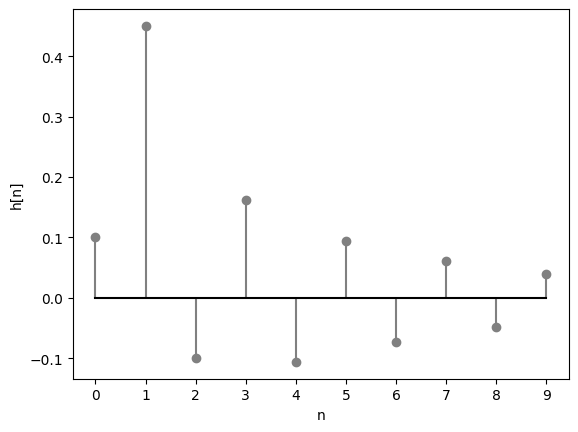

In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

#b, a = sp.signal.iirfilter(1, 0.2, rs=60, btype='lowpass')

#w, h = sp.signal.freqs(b, a, 10)
#x, h = sp.signal.impulse([b,a],N=4)

b = [0.1, 0.5,  0.1]
a = [1,   0.5,  -.25]

x    = np.zeros(10)
x[0] = 1

h = sp.signal.lfilter(b, a, x)

#print("b = ",b)
#print("a = ",a)

#x,h = sp.signal.impulse([b,a],N=4)

#print('h =',h[0:10])

plt.stem(h, 'gray', markerfmt='gray', basefmt='k')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.xticks([0,1,2,3,4,5,6,7,8,9,])
plt.show();